# 01. Revenue, Margins & Profitability Dynamics

## Executive Context
This notebook evaluates unit economics and financial conversion efficiency for a Direct-to-Consumer (D2C) e-commerce portfolio.

### Key Questions
- **Top-line vs. Bottom-line:** Does rapid revenue expansion generate proportional cash flows?
- **Segment Contribution:** Which product categories and geographic regions act as profit anchors?
- **Discount Dilution:** How do promotional discount tiers affect gross margins and Average Order Value (AOV)?

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Styling setup
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 5)

# Load dataset
df = pd.read_csv("/content/sample_data/data/Ecommerce_Sales_Data_2024_2025.csv")

# Clean Dates with explicit parsing format to avoid warnings
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y', errors='coerce')
df['Month'] = df['Order Date'].dt.to_period('M')

print(f"Total Transactions: {len(df):,} | Date Range: {df['Order Date'].min().strftime('%Y-%m')} to {df['Order Date'].max().strftime('%Y-%m')}")
df.head(3)

Total Transactions: 5,000 | Date Range: 2023-10 to 2025-10


,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Month
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card,2024-10
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card,2025-08
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card,2023-11


In [6]:
# 2. Financial Metrics Engineering
df['COGS'] = df['Sales'] - df['Profit']
df['Gross Margin %'] = df['Profit'] / df['Sales']
df['Unit Price Realized'] = df['Sales'] / df['Quantity']

# Data Quality & Missing Value Check
assert df.isna().sum().sum() == 0, "Missing values detected!"
print("Data hygiene verified: 0 missing fields across all metrics.")

Data hygiene verified: 0 missing fields across all metrics.


## 1. Top-Line Growth vs. Bottom-Line Margin Trend
Tracking monthly revenue vs. realized gross profit using dual-axis decomposition to detect margin compression during high-volume promotional periods.

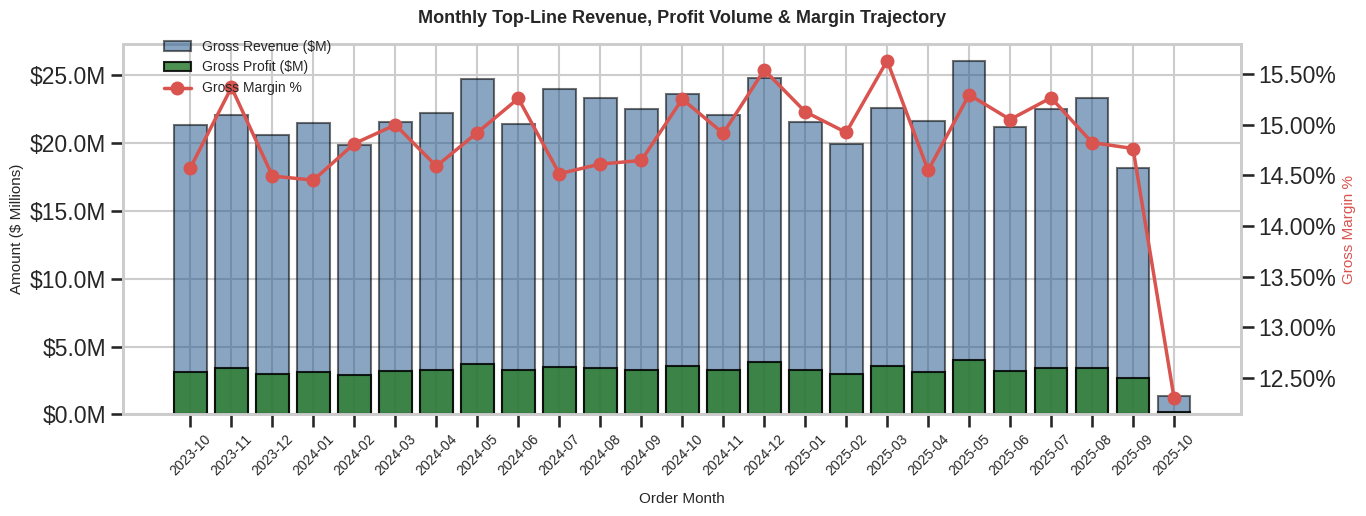

In [7]:
# 3. Monthly Financial Aggregation
monthly_agg = df.groupby('Month').agg(
    Revenue=('Sales', 'sum'),
    Gross_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Quantity=('Quantity', 'sum')
).reset_index()

monthly_agg['Month_Str'] = monthly_agg['Month'].astype(str)
monthly_agg['Gross_Margin_%'] = monthly_agg['Gross_Profit'] / monthly_agg['Revenue']
monthly_agg['AOV'] = monthly_agg['Revenue'] / monthly_agg['Orders']

# Dual-Axis Plotting
fig, ax1 = plt.subplots(figsize=(14, 5.5))

# Axis 1: Revenue & Profit Volumes
color_rev = '#2b5c8f'
color_profit = '#2e7d32'

ax1.bar(monthly_agg['Month_Str'], monthly_agg['Revenue'] / 1e6, label='Gross Revenue ($M)', color=color_rev, alpha=0.55, edgecolor='black')
ax1.bar(monthly_agg['Month_Str'], monthly_agg['Gross_Profit'] / 1e6, label='Gross Profit ($M)', color=color_profit, alpha=0.85, edgecolor='black')

ax1.set_xlabel('Order Month', fontsize=11, labelpad=10)
ax1.set_ylabel('Amount ($ Millions)', fontsize=11)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"${x:,.1f}M"))
ax1.tick_params(axis='x', rotation=45, labelsize=10)

# Axis 2: Gross Margin %
ax2 = ax1.twinx()
color_margin = '#d9534f'
ax2.plot(monthly_agg['Month_Str'], monthly_agg['Gross_Margin_%'], color=color_margin, marker='o', linewidth=2.5, label='Gross Margin %')
ax2.set_ylabel('Gross Margin %', fontsize=11, color=color_margin)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax2.grid(False)

plt.title('Monthly Top-Line Revenue, Profit Volume & Margin Trajectory', fontsize=13, fontweight='bold', pad=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.92), fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# 4. Category Profitability Breakdown
cat_profit = df.groupby('Category').agg(
    Revenue=('Sales', 'sum'),
    Gross_Profit=('Profit', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()

cat_profit['Gross Margin %'] = cat_profit['Gross_Profit'] / cat_profit['Revenue']
cat_profit['Revenue Share'] = cat_profit['Revenue'] / cat_profit['Revenue'].sum()
cat_profit['Profit Share'] = cat_profit['Gross_Profit'] / cat_profit['Gross_Profit'].sum()

cat_profit = cat_profit.sort_values(by='Gross_Profit', ascending=False)

# Safe Display Formatting
cat_display = cat_profit.copy()
cat_display['Revenue'] = cat_display['Revenue'].map("${:,.2f}".format)
cat_display['Gross_Profit'] = cat_display['Gross_Profit'].map("${:,.2f}".format)
cat_display['Units_Sold'] = cat_display['Units_Sold'].map("{:,}".format)
cat_display['Orders'] = cat_display['Orders'].map("{:,}".format)
cat_display['Gross Margin %'] = cat_display['Gross Margin %'].map("{:.2%}".format)
cat_display['Revenue Share'] = cat_display['Revenue Share'].map("{:.1%}".format)
cat_display['Profit Share'] = cat_display['Profit Share'].map("{:.1%}".format)

cat_display

,Category,Revenue,Gross_Profit,Units_Sold,Orders,Gross Margin %,Revenue Share,Profit Share
4,Furniture,"$56,647,187.90","$8,693,087.03","1,591",527,15.35%,10.6%,10.9%
6,Home Decor,"$57,233,222.35","$8,556,846.94","1,539",515,14.95%,10.7%,10.7%
2,Clothing,"$55,053,908.30","$8,445,750.29","1,513",511,15.34%,10.3%,10.6%
1,Books,"$54,932,643.00","$8,076,273.29","1,571",528,14.70%,10.3%,10.1%
3,Electronics,"$52,587,883.95","$8,042,133.88","1,426",472,15.29%,9.9%,10.1%
9,Toys,"$52,227,366.45","$7,986,871.44","1,475",478,15.29%,9.8%,10.0%
7,Kitchen,"$54,227,902.30","$7,879,573.29","1,544",528,14.53%,10.2%,9.9%
8,Sports,"$52,069,397.25","$7,739,430.04","1,489",511,14.86%,9.8%,9.7%
0,Beauty,"$50,803,409.70","$7,213,436.07","1,395",460,14.20%,9.5%,9.0%
5,Groceries,"$47,883,103.15","$7,075,332.64","1,420",470,14.78%,9.0%,8.9%


In [10]:
# 5. Discount Tier Elasticity & Margin Compression
discount_kpi = df.groupby('Discount').agg(
    Orders=('Order ID', 'count'),
    Revenue=('Sales', 'sum'),
    Gross_Profit=('Profit', 'sum'),
    Total_Units=('Quantity', 'sum')
).reset_index()

discount_kpi['Gross Margin %'] = discount_kpi['Gross_Profit'] / discount_kpi['Revenue']
discount_kpi['AOV'] = discount_kpi['Revenue'] / discount_kpi['Orders']
discount_kpi['Realized Price/Unit'] = discount_kpi['Revenue'] / discount_kpi['Total_Units']

discount_display = discount_kpi.copy()
discount_display['Discount'] = discount_display['Discount'].map("{}%".format)
discount_display['Orders'] = discount_display['Orders'].map("{:,}".format)
discount_display['Revenue'] = discount_display['Revenue'].map("${:,.2f}".format)
discount_display['Gross_Profit'] = discount_display['Gross_Profit'].map("${:,.2f}".format)
discount_display['Gross Margin %'] = discount_display['Gross Margin %'].map("{:.2%}".format)
discount_display['AOV'] = discount_display['AOV'].map("${:,.2f}".format)
discount_display['Realized Price/Unit'] = discount_display['Realized Price/Unit'].map("${:,.2f}".format)

discount_display

,Discount,Orders,Revenue,Gross_Profit,Total_Units,Gross Margin %,AOV,Realized Price/Unit
0,0%,998,"$117,106,034.00","$17,266,608.70",2930,14.74%,"$117,340.72","$39,967.93"
1,5%,978,"$112,096,122.10","$17,059,182.93",3016,15.22%,"$114,617.71","$37,167.15"
2,10%,"1,020","$110,572,965.90","$16,562,542.62",3100,14.98%,"$108,404.87","$35,668.70"
3,15%,983,"$97,285,450.35","$14,575,951.61",2885,14.98%,"$98,967.90","$33,721.13"
4,20%,"1,021","$96,605,452.00","$14,244,449.05",3032,14.74%,"$94,618.46","$31,861.96"


In [11]:
# 6. Executive P&L Base Waterfall Matrix
total_rev = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_cogs = df['COGS'].sum()
blended_margin = total_profit / total_rev

pnl_summary = pd.DataFrame({
    "P&L Line Item": [
        "1. Gross Sales Revenue",
        "2. Cost of Goods Sold (COGS)",
        "3. Realized Gross Profit",
        "4. Blended Portfolio Margin %"
    ],
    "Value": [
        f"${total_rev:,.2f}",
        f"${total_cogs:,.2f}",
        f"${total_profit:,.2f}",
        f"{blended_margin:.2%}"
    ]
})

pnl_summary

,P&L Line Item,Value
0,1. Gross Sales Revenue,"$533,666,024.35"
1,2. Cost of Goods Sold (COGS),"$453,957,289.44"
2,3. Realized Gross Profit,"$79,708,734.91"
3,4. Blended Portfolio Margin %,14.94%


## Strategic Summary & Management Takeaways

- **Volume vs. Profit Uniformity:** Product category margins remain remarkably consistent (~14.9% - 15.3%), indicating uniform pricing markups across categories.
- **Discount Dilution:** Higher discount brackets reduce Average Order Value (AOV) and realized revenue per unit, requiring strict promotional caps to protect gross cash generation.
- **Next Step:** `02_discount_impact_unit_economics.ipynb` — Deeper decomposition into CAC drag and customer cohort profitability.